In [2]:
import sys, os
import pandas as pd
from utils.misc import cols_to_front
from pathlib import Path
from datetime import datetime
import shutil
import nbformat
from nbconvert.preprocessors import ExecutePreprocessor
import subprocess
import yaml
import seaborn as sns
import matplotlib.pyplot as plt

with open('config/config.yaml', 'r') as file:
    config = yaml.safe_load(file)

In [3]:
history_file = Path("runs") / "local_flavordb_similarity_history.xlsx"

In [4]:
df = pd.read_excel(history_file)
# extract fields from run_name
pattern = (
    r'(?P<exp_name>.+?)'
    r'_rd-(?P<reduce_dim>true|false)'
    r'_meth-(?P<method>\w+)'
    r'_dim-(?P<n_dim>\d+)'
    r'_idf-(?P<idf>true|false)'
    r'_(?P<date>\d{4}-\d{2}-\d{2})'
    r'_(?P<time>\d{2}-\d{2})'
)

parsed = df["run_name"].str.extract(pattern)

# merge with original dataframe
df = pd.concat([df, parsed], axis=1)

# convert types
df["reduce_dim"] = df["reduce_dim"].map({"true": True, "false": False})
df["idf"] = df["idf"].map({"true": True, "false": False})
df["n_dim"] = df["n_dim"].astype(int)

df.head()

,run_name,category,flavor_vs_local,flavor_vs_flavor,local_vs_local,flavor_count,local_count,exp_name,reduce_dim,method,n_dim,idf,date,time
0,GPT52-RAG_rd-true_meth-pca_dim-100_idf-false_2...,plant,0.023,0.049,0.132,45.0,68.0,GPT52-RAG,True,pca,100,False,2026-03-05,12-43
1,GPT52-RAG_rd-true_meth-pca_dim-100_idf-false_2...,fungus,0.291,0.314,0.359,11.0,14.0,GPT52-RAG,True,pca,100,False,2026-03-05,12-43
2,GPT52-RAG_rd-true_meth-pca_dim-100_idf-false_2...,vegetable,0.076,0.144,0.181,41.0,11.0,GPT52-RAG,True,pca,100,False,2026-03-05,12-43
3,GPT52-RAG_rd-true_meth-pca_dim-100_idf-false_2...,root,0.077,0.173,0.132,18.0,43.0,GPT52-RAG,True,pca,100,False,2026-03-05,12-43
4,GPT52-RAG_rd-true_meth-pca_dim-100_idf-false_2...,fruit,0.020,0.151,0.157,81.0,9.0,GPT52-RAG,True,pca,100,False,2026-03-05,12-43


In [ ]:
# build readable label for splitting runs 
df["run_label"] = df["method"] + "_dim" + df["n_dim"].astype(str)

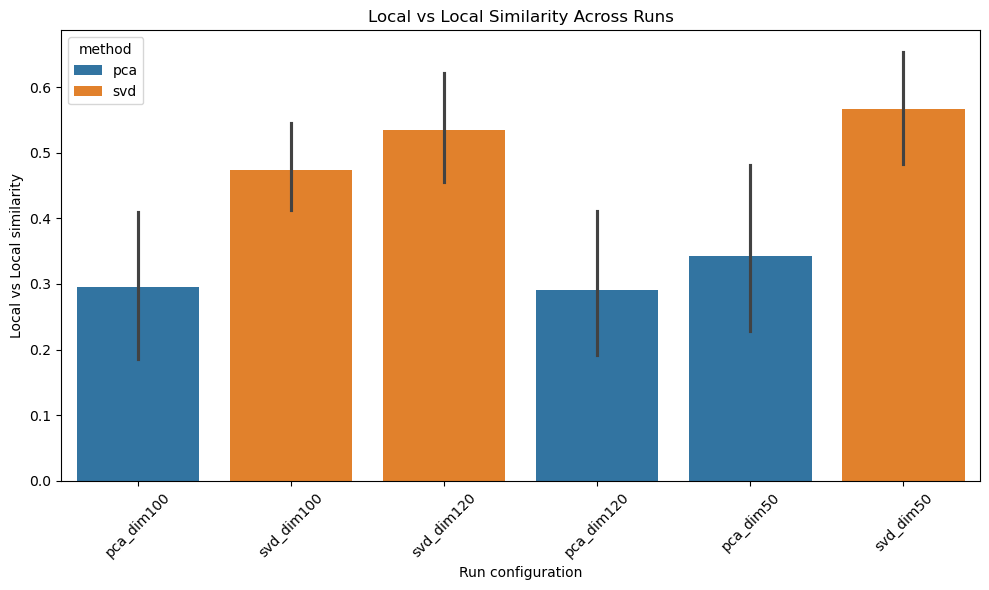

In [5]:
# Overview by category - not weighted

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="run_label",
    y="local_vs_local",
    hue="method"
)

plt.xlabel("Run configuration")
plt.ylabel("Local vs Local similarity")
plt.title("Local vs Local Similarity Across Runs")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

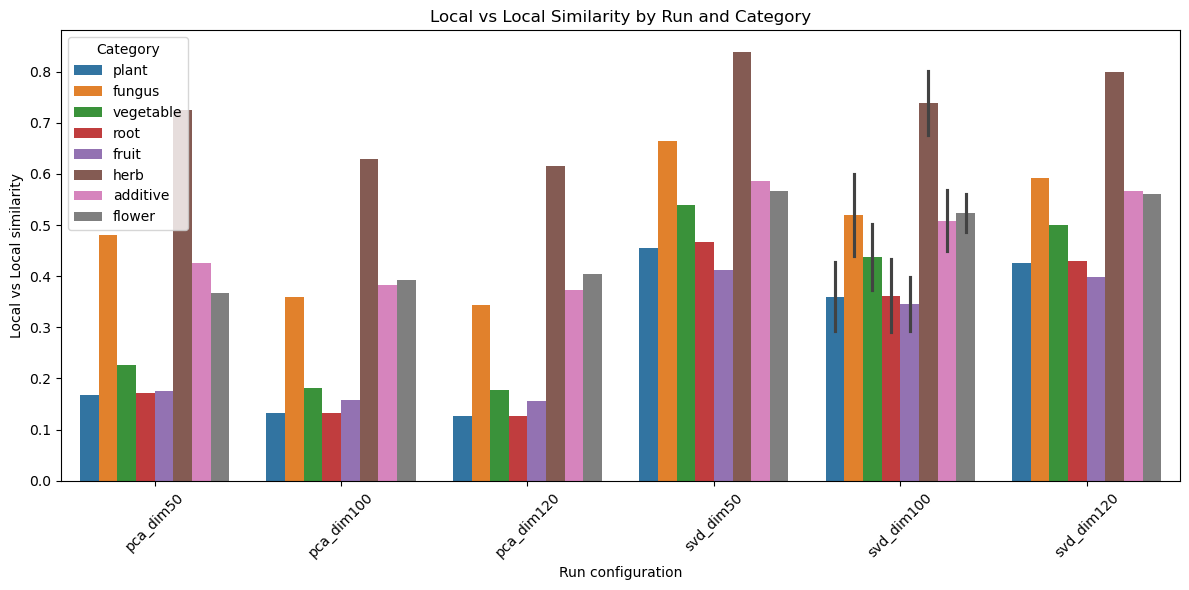

In [6]:
# create readable run label
df["run_label"] = df["method"] + "_dim" + df["n_dim"].astype(str)

# optional: keep runs ordered
df = df.sort_values(["method", "n_dim"])

plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="run_label",
    y="local_vs_local",
    hue="category"
)

plt.xlabel("Run configuration")
plt.ylabel("Local vs Local similarity")
plt.title("Local vs Local Similarity by Run and Category")

plt.xticks(rotation=45)
plt.legend(title="Category")

plt.tight_layout()
plt.show()